In [2]:
import sys
print(sys.executable)


/opt/miniconda3/bin/python


In [3]:
%matplotlib inline
import spiceypy as sp
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [4]:
import os

# --- Ruta absoluta al meta-kernel v533 ---
METAK = os.path.abspath(
    os.path.join(
        os.getcwd(),
        '..', 'kernels', 'mk',
        'em16_plan_v533_20250425_001.tm'
    )
)

In [5]:
def carga_kernels():
    """Carga el meta-kernel situándose en el directorio kernels/mk."""
    meta_dir = os.path.dirname(METAK)
    print("⤷ Cambiando directorio a:", meta_dir)
    os.chdir(meta_dir)
    tm_file = os.path.basename(METAK)
    print("⤷ Cargando meta-kernel:", tm_file)
    sp.furnsh(tm_file)

carga_kernels()

⤷ Cambiando directorio a: /Users/aw/SpiceKernelsMEX/exomars2016/kernels/mk
⤷ Cargando meta-kernel: em16_plan_v533_20250425_001.tm


In [6]:
from datetime import datetime, timedelta

# Convert ET times to Spice format
et0 = sp.str2et("2021-04-01T00:00:00")
et1 = sp.str2et("2021-05-01T00:00:00")
step = 60  # 60 seconds

# Create a list of times from 1-30 Apr, in 60s intervals
ets = np.arange(et0, et1, step)
angulos = [] # off-nadir angles
tiempos = []

for et in ets:
    # Vector from TGO to the center of Mars in the TGO frame of reference
    vec, _ = sp.spkpos("MARS", et, "TGO_SPACECRAFT", "NONE", "TGO_SPACECRAFT")
    
    # Matriz de actitud: de J2000 a TGO
    mat = sp.pxform("TGO_SPACECRAFT", "J2000", et)
    
    # The -Y axis in TGO is [0, -1, 0] (already in the frame of the satellite)
    y_axis = np.array([0, -1, 0])
    
    # The vector towards Mars is already in TGO, no need to transform it
    # Calculate the angle between the y axis and the vector calculated
    cos_theta = np.dot(y_axis, vec) / (np.linalg.norm(y_axis) * np.linalg.norm(vec))
    theta = np.arccos(np.clip(cos_theta, -1.0, 1.0))  # en radianes
    ang_deg = np.degrees(theta)

    angulos.append(ang_deg)
    tiempos.append(sp.et2datetime(et))

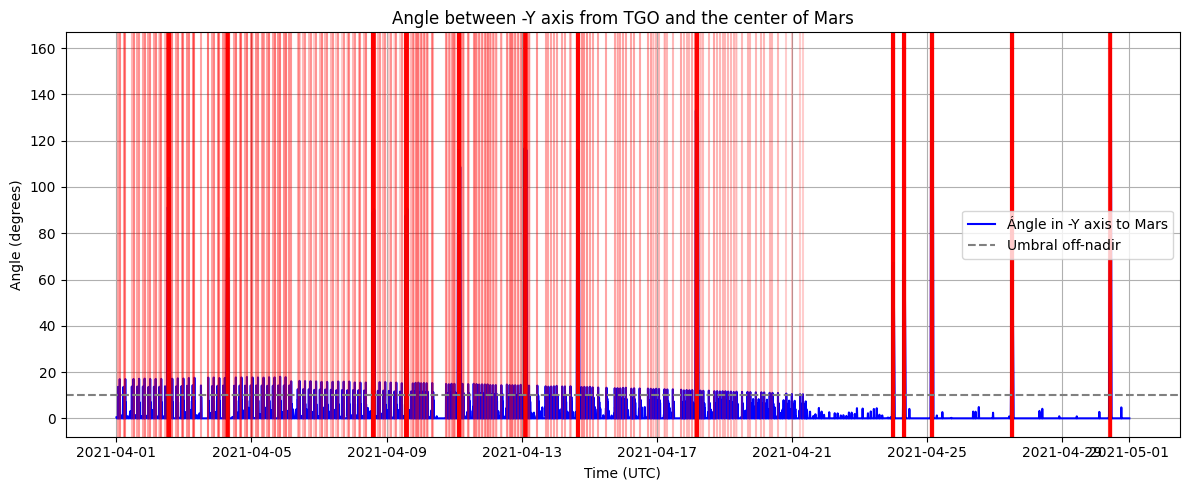

In [ ]:
# Define off-nadir threshold
umbral_off_nadir = 10.0  # degrees

# Crete figure
plt.figure(figsize=(12, 5))
plt.plot(tiempos, angulos, label="Ángle in -Y axis to Mars", color="blue")

# Shade areas off-nadir
for t, ang in zip(tiempos, angulos):
    if ang > umbral_off_nadir:
        plt.axvline(t, color='red', alpha=0.1)

# Labels
plt.axhline(umbral_off_nadir, color='gray', linestyle='--', label="Off-nadir threshold")
plt.title("Angle between -Y axis from TGO and the center of Mars")
plt.xlabel("Time (UTC)")
plt.ylabel("Angle (degrees)")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


In [8]:
# Umbral de off-nadir
umbral = 10

# Convertimos a array para facilitar la operación
tiempos = np.array(tiempos)
angulos = np.array(angulos)

# Detectar dónde está en off-nadir
off_nadir = angulos > umbral

# Identificar transiciones (inicio y fin de zonas off-nadir)
cambios = np.diff(off_nadir.astype(int))
inicios = np.where(cambios == 1)[0] + 1
finales = np.where(cambios == -1)[0] + 1

# Ajustar bordes si comienza o termina en off-nadir
if off_nadir[0]:
    inicios = np.insert(inicios, 0, 0)
if off_nadir[-1]:
    finales = np.append(finales, len(off_nadir) - 1)


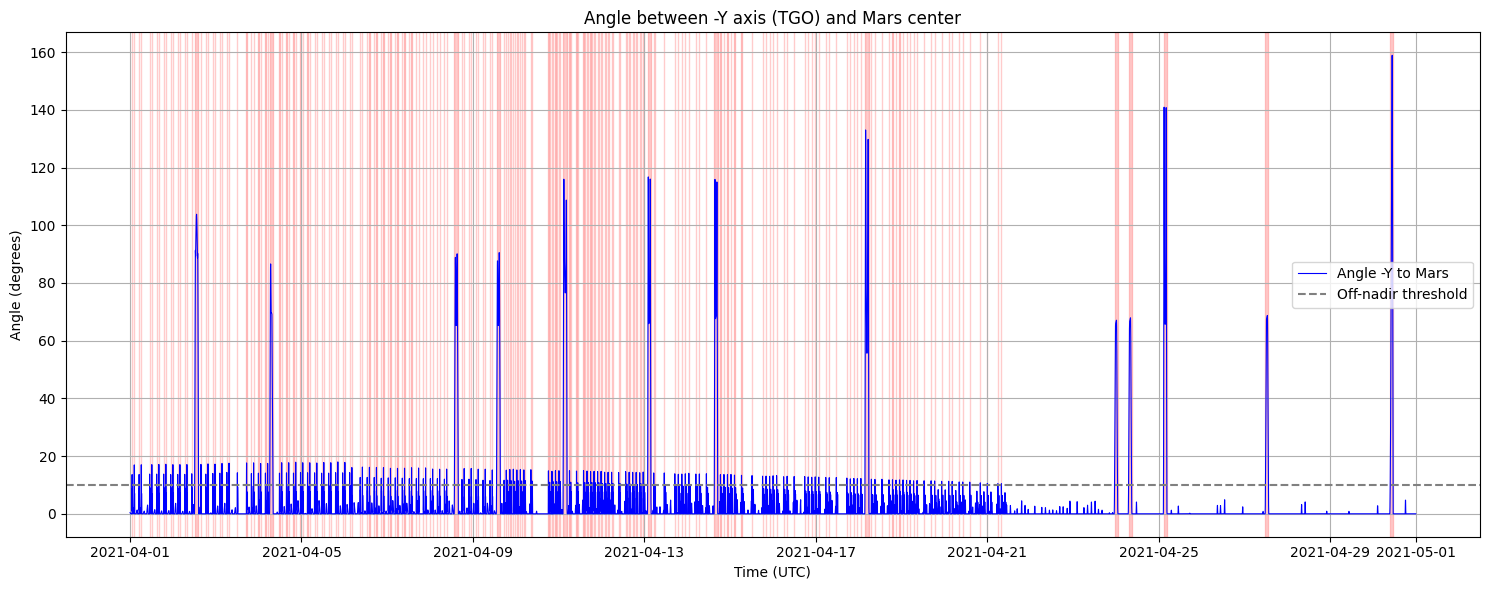

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(tiempos, angulos, label="Angle -Y to Mars", color="blue", lw=0.8)
plt.axhline(y=umbral, color="gray", linestyle="--", label="Off-nadir threshold")

# Sombrear periodos off-nadir
for start, end in zip(inicios, finales):
    plt.axvspan(tiempos[start], tiempos[end], color="red", alpha=0.2)

plt.xlabel("Time (UTC)")
plt.ylabel("Angle (degrees)")
plt.title("Angle between -Y axis (TGO) and Mars center")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
